# PC Causal Discovery Demo

PC is a constraint-based method. Here it is applied to a lag-expanded view of a small time series so that the ground-truth edges are known.

In [ ]:
!pip3 install -q git+https://github.com/NetManAIOps/sktime.git causal-learn tigramite matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

from sktime.causal_discovery import PC

In [2]:
VARIABLES = ["Driver", "Mediator", "Outcome"]

TRUE_LAGGED_EDGES = {
    ("Driver[t-1]", "Driver[t]"),
    ("Driver[t-1]", "Mediator[t]"),
    ("Mediator[t-1]", "Mediator[t]"),
    ("Mediator[t-1]", "Outcome[t]"),
    ("Outcome[t-1]", "Outcome[t]"),
}


def make_lagged_chain(n=700, burn_in=80, seed=8):
    rng = np.random.default_rng(seed)
    x = np.zeros((n, 3))
    noise = rng.normal(scale=0.8, size=(n, 3))

    for t in range(1, n):
        x[t, 0] = 0.65 * x[t - 1, 0] + noise[t, 0]
        x[t, 1] = 0.45 * x[t - 1, 1] + 0.85 * x[t - 1, 0] + noise[t, 1]
        x[t, 2] = 0.40 * x[t - 1, 2] + 0.75 * x[t - 1, 1] + noise[t, 2]

    X = pd.DataFrame(x[burn_in:], columns=VARIABLES)
    return (X - X.mean()) / X.std()


def make_lagged_table(X):
    return pd.concat(
        [X.add_suffix("[t-1]").shift(1), X.add_suffix("[t]")], axis=1
    ).dropna()


X_ts = make_lagged_chain()
X_lagged = make_lagged_table(X_ts)

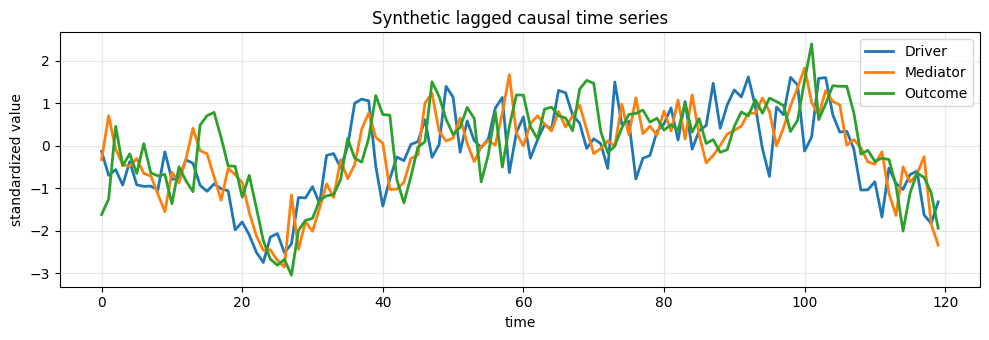

In [3]:
ax = X_ts.iloc[:120].plot(figsize=(10, 3.5), linewidth=2)
ax.set_title("Synthetic lagged causal time series")
ax.set_xlabel("time")
ax.set_ylabel("standardized value")
ax.grid(alpha=0.3)
plt.tight_layout()

## Indirect correlation check

Driver[t-1] is correlated with Outcome[t], although the direct parent of Outcome[t] is Mediator[t-1]. This is the simple teaching trap: a causal discovery method should avoid turning every correlation into a direct edge.

In [4]:
pd.DataFrame(
    {
        "correlation with Outcome[t]": {
            "Driver[t-1]": X_lagged["Driver[t-1]"].corr(X_lagged["Outcome[t]"]),
            "Mediator[t-1]": X_lagged["Mediator[t-1]"].corr(X_lagged["Outcome[t]"]),
        }
    }
)

,correlation with Outcome[t]
Driver[t-1],0.499964
Mediator[t-1],0.888960


In [5]:
COLORS = {
    "correct": "#2ca02c",
    "false positive": "#d62728",
    "missed": "#8c8c8c",
    "reversed": "#ff7f0e",
}

POSITIONS = {
    "Driver[t-1]": (0, 2),
    "Mediator[t-1]": (0, 1),
    "Outcome[t-1]": (0, 0),
    "Driver[t]": (1, 2),
    "Mediator[t]": (1, 1),
    "Outcome[t]": (1, 0),
}


def status_for_edge(source, target, kind, true_edges):
    if (source, target) in true_edges:
        return "correct"
    if kind == "undirected" and (target, source) in true_edges:
        return "correct"
    if (target, source) in true_edges:
        return "reversed"
    return "false positive"


def covered_true_edges(pred_edges, true_edges):
    covered = set()
    for source, target, kind in pred_edges:
        if (source, target) in true_edges:
            covered.add((source, target))
        if (target, source) in true_edges:
            covered.add((target, source))
    return covered


def edge_table(pred_edges, true_edges):
    rows = []
    for source, target, kind in pred_edges:
        rows.append(
            {
                "source": source,
                "target": target,
                "type": kind,
                "status": status_for_edge(source, target, kind, true_edges),
            }
        )
    for source, target in sorted(true_edges - covered_true_edges(pred_edges, true_edges)):
        rows.append(
            {"source": source, "target": target, "type": "true edge", "status": "missed"}
        )
    return pd.DataFrame(rows)


def draw_edge(ax, source, target, color, kind="directed", linestyle="-", rad=0.04):
    arrowstyle = "-|>" if kind == "directed" else "-"
    patch = FancyArrowPatch(
        POSITIONS[source],
        POSITIONS[target],
        arrowstyle=arrowstyle,
        mutation_scale=14,
        linewidth=2.5,
        color=color,
        linestyle=linestyle,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=20,
        shrinkB=20,
    )
    ax.add_patch(patch)


def plot_causal_graph(pred_edges, true_edges, title):
    fig, ax = plt.subplots(figsize=(9, 4.5))

    missed_edges = true_edges - covered_true_edges(pred_edges, true_edges)
    for source, target in missed_edges:
        draw_edge(ax, source, target, COLORS["missed"], linestyle="--", rad=-0.05)

    for source, target, kind in pred_edges:
        status = status_for_edge(source, target, kind, true_edges)
        draw_edge(ax, source, target, COLORS[status], kind=kind)

    for node, (x, y) in POSITIONS.items():
        ax.text(
            x,
            y,
            node,
            ha="center",
            va="center",
            fontsize=11,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "black", "lw": 1.2},
        )

    ax.text(0, 2.55, "lagged variables", ha="center", fontsize=12)
    ax.text(1, 2.55, "current variables", ha="center", fontsize=12)
    ax.set_title(title)
    ax.set_xlim(-0.45, 1.45)
    ax.set_ylim(-0.55, 2.85)
    ax.axis("off")

    legend = [
        Line2D([0], [0], color=COLORS["correct"], lw=3, label="correct edge"),
        Line2D([0], [0], color=COLORS["false positive"], lw=3, label="false positive"),
        Line2D([0], [0], color=COLORS["missed"], lw=3, ls="--", label="missed true edge"),
        Line2D([0], [0], color=COLORS["reversed"], lw=3, label="reversed direction"),
    ]
    ax.legend(handles=legend, loc="lower center", ncol=4, frameon=False)
    plt.tight_layout()

In [6]:
def cpdag_edge_list(adjacency, names):
    edges = []
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if adjacency[i, j] == 1:
                edges.append((source, target, "directed"))
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if i < j and adjacency[i, j] == -1 and adjacency[j, i] == -1:
                edges.append((source, target, "undirected"))
    return edges

In [7]:
pc = PC(alpha=0.05)
pc.fit(X_lagged)

names = list(X_lagged.columns)
adjacency = pc.get_adjacency_matrix()
pred_edges = cpdag_edge_list(adjacency, names)
pred_edges

/Users/moonshot/Project/sktime/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[('Driver[t-1]', 'Driver[t]', 'undirected'),
 ('Driver[t-1]', 'Mediator[t]', 'undirected'),
 ('Mediator[t-1]', 'Outcome[t-1]', 'undirected'),
 ('Mediator[t-1]', 'Mediator[t]', 'undirected'),
 ('Mediator[t-1]', 'Outcome[t]', 'undirected'),
 ('Outcome[t-1]', 'Outcome[t]', 'undirected')]

In [8]:
edge_table(pred_edges, TRUE_LAGGED_EDGES)  # cpdag comparison

,source,target,type,status
0,Driver[t-1],Driver[t],undirected,correct
1,Driver[t-1],Mediator[t],undirected,correct
2,Mediator[t-1],Outcome[t-1],undirected,false positive
3,Mediator[t-1],Mediator[t],undirected,correct
4,Mediator[t-1],Outcome[t],undirected,correct
5,Outcome[t-1],Outcome[t],undirected,correct


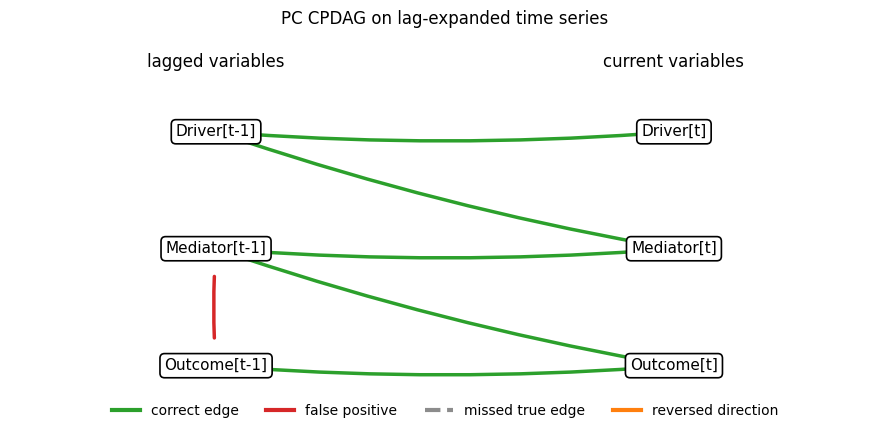

In [9]:
plot_causal_graph(pred_edges, TRUE_LAGGED_EDGES, "PC CPDAG on lag-expanded time series")